# 1 Initialize the Database

All the code related to data management is in the `EnvironmentData` class. This makes life easier - for example: we can send the CatsUserID once and it becomes a class property. Then, when we call other operations we don't have to send this information again.

When you create a new instance of `EnvironmentData` and there is no database, it'll pull historical data and initialize the database. 

In [1]:
# clear prior data. 
import os, shutil
if os.path.exists('data'):
    shutil.rmtree('data')
    os.makedirs('data')

from EnvironmentData import EnvironmentData 
#envdt = EnvironmentData(CatsUserID = 2496, days_back = 365 * 2, out_of_scope = ['-80', 'Cryo tank', 'Water'], testing = True)
envdt = EnvironmentData(CatsUserID = 2496, out_of_scope = ['-80', 'Cryo tank', 'Water'])

Gather readings: SensorReadingRh: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65/65 [03:46<00:00,  3.49s/it]


Detailed information is saved in the log:

In [2]:
# Detailed info is saved in the log.
with open('data/EnvironmentData.log', 'r') as file:
    for line in file.read().splitlines()[:10]:
        print(line)

2024-10-18 11:58:33,984 - EnvironmentData - INFO - initialize_database
2024-10-18 11:58:33,984 - EnvironmentData - INFO - get_sensors
2024-10-18 11:58:33,984 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/cats/user/?ApiKey=XXXX&CatsUserID=XXXX
2024-10-18 11:58:35,056 - EnvironmentData - INFO - get_sensors validation: correct column data types.
2024-10-18 11:58:35,057 - EnvironmentData - INFO - get_sensors validation: at least one non-null value in readings.
2024-10-18 11:58:35,057 - EnvironmentData - INFO - get_sensors validation: no duplicated SensorReadingUTC per SensorID_Coris.
2024-10-18 11:58:35,058 - EnvironmentData - INFO - get_sensors validation: one SensorName per SensorID_Coris.
2024-10-18 11:58:35,067 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21373&ReadingType=SensorReadingF&StartUTC=1666202313&EndUTC=1729274313&MinReadingSpacing=600&RequestedOutputFormat=raw
2024-10-18 11:58:3

Raw data is now in the database in `data/sensor_readings.parquet`. 

Initially, we leave the data mostly as-is. We'll clean when moving to analytical steps, this preserves the source data so we can always change our mind about how we decide to view it. 

There are just a few columns because this is only historical data. We'll bring in current data shortly, and that will add more columns. 

In [3]:
import polars
polars.read_parquet('data/sensor_readings.parquet')

SensorReadingUTC,SensorReadingF,SensorID_Coris,SensorName,DeviceName,DeviceID_Coris,SensorType,SensorReadingRh
i64,f32,i32,str,str,i32,str,f32
1666202313,67.139999,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666202913,67.139999,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666203513,67.059998,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666204113,66.989998,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666204713,66.970001,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
…,…,…,…,…,…,…,…
1729271313,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",42.400002
1729271913,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",42.099998
1729272513,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",42.099998


# 2 Get Current Readings

Now we can start gathering and appending readings. There is a function `get_current_readings` that is run throughout the day, every 10 minutes for example. This function creates a parquet file at `data/new-readings` with the UTC as a filename. At the end of the day, all these readings will be consolidated into the database. 

Here is a sample of the readings:

In [4]:
envdt.get_current_readings()

# Data is read into new-readings folder for consolidation at the end of the day.
import os
filename = os.listdir('data/new-readings')[0]
print(filename)
polars.read_parquet('data/new-readings/' + filename).sample(5)

C:\Users\super\Documents\environmental-sensor-poc\environmental-sensor-poc\EnvironmentData.py:122: UserWarning:  validation errors : SensorReadingUTC differs from UTC: UTC: 1729274777, maximum absolute difference (minutes): 5e+05.

  warnings.warn(msg)


1729274777.parquet


SensorName,SensorID_Coris,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,SensorReadingUTC,DeviceName,DevTypeInt,DeviceID_Coris,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorType,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorReadingF,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorReadingRh,SensorCalibrationOffsetRh,SensorEventCount,SensorState,QueryUTC
str,i32,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,i64,i32,str,null,str,str,null,str,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f32,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,f32,i64,i64,str,i32
"""RH ESC 255_8404e3""",25959,0,1729274777,"""000000000000""","""0080000000019E54""",1729274772,false,"""Excellent""","""A8404165118404E3""",false,false,31.0,1729274546,"""D_a8404165118404e3""",112,12929,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,null,1,null,85,1729274510,0,null,null,38863,null,null,null,null,null,null,null,null,0,31.0,0,null,null,1729274777
"""Temp CSC N551_00cd81""",23374,0,1729274777,"""000000000000""","""0080000000019E62""",1729274756,false,"""Excellent""","""0025CA0A0000CD81""",false,false,19.27,1729274569,"""L_0025CA0A0000CD81""",96,12412,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,19.3,0.0,66.699997,0.0,null,null,null,null,1,0,70,1729273127,0,null,null,35766,null,40.87,40.87,23375,1729274569,66.7,19.3,0,0,null,null,null,null,1729274777
"""RH KGL 105_8404fd""",25967,0,1729274777,"""000000000000""","""0080000000019E44""",1729274761,false,"""Good""","""A8404159618404FD""",false,false,33.1,1729274883,"""Yale Peabody 8404fd""",112,12922,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,null,1,null,85,1729274742,0,null,null,38871,null,null,null,null,null,null,null,null,0,33.099998,0,null,null,1729274777
"""Temp CSC K217_00cda7""",23378,0,1729274777,"""000000000000""","""0080000000019E79""",1729274769,false,"""Excellent""","""0025CA0A0000CDA7""",false,false,20.93,1729274745,"""L_0025CA0A0000CDA7""",96,12425,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,20.9,0.0,69.699997,0.0,null,null,null,null,1,0,70,1729240182,0,null,null,35770,null,50.26,50.26,23379,1729274745,69.7,20.9,0,0,null,null,null,null,1729274777
"""Temp ESC 255_8404e3""",25958,0,1729274777,"""000000000000""","""0080000000019E54""",1729274772,false,"""Excellent""","""A8404165118404E3""",false,false,21.17,1729274546,"""D_a8404165118404e3""",112,12929,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,300,21.2,0.0,70.099998,0.0,null,null,null,null,1,null,85,1729274510,0,null,null,38862,nu

# 3 Consolidate Readings

At the end of the day, new readings will be consolidated into the table. At the same time, the analytical tables will be generated. 

Analytical tables include:

* `device_readings.parquet`: Sensor readings reorganized to one row per Device and UTC, with measurements across columns vs measurements across rows.* 
* `sensors.parquet`: Information about the unique sensors. Includes information extracted from SensorName. Join this to Sensors during analysis to enhance with Building, Room, Direction, etc.
* `devices.parquet`: Information about unique devices. Includes information extracted from SensorName. 
* `utcs.parquet`: Information related to the UTC times in various datasets. Join to Sensors or Devices to enhance with Date, Time, Year, Hour, Weekday, etc.
* `sensor_readings_daily.parquet`: Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries.
* `device_readings_daily.parquet`: Example of device readings summarized to the daily level which reduces row count by 99.3% for even faster queries. 

We fully re-generate analytical tables during each consolidation. The data is small enough that this is a fairly quick process, so re-running it in full each time will make it easy to ensure consistency as we expand and change the project. 

In [5]:
# To consolidate these into the database, run consolidate_readings.
envdt.consolidate_readings()

# New-readings files are gone now.
# They get deleted each day to confirm that they have been loaded into the database and prepare for the next consolidation.
print(os.listdir('data/new-readings'))

C:\Users\super\Documents\environmental-sensor-poc\environmental-sensor-poc\EnvironmentData.py:122: UserWarning: Validation errors: 
1 missing values in [SensorReadingRh].
  warnings.warn(msg)


[]


Let's look at the data we have now:

In [6]:
# Sensor Readings
# The first rows will be missing the extra fields like HexGatewayMac, etc.
#   I am pulling in some extra fields like DeviceID and DeviceName so we have that by historical. 
#   But some don't make sense to  backfill so they'll be null.
sensor_readings = polars.read_parquet('data/sensor_readings.parquet')
sensor_readings.head()

SensorID_Coris,QueryUTC,SensorReadingUTC,DeviceID_Coris,SensorReadingUTC_SecondsFromPrior,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,i32,i64,i32,i64,f32,f32,str,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
21373,null,1666202313,12162,null,67.139999,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666202913,12162,600,67.139999,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666203513,12162,600,67.059998,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666204113,12162,600,66.989998,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666204713,12162,600,66.970001,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [7]:
# Recent rows will have the full data, aside from nulls due to a sensor not providing a reading type\.
sensor_readings.tail()

SensorID_Coris,QueryUTC,SensorReadingUTC,DeviceID_Coris,SensorReadingUTC_SecondsFromPrior,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,i32,i64,i32,i64,f32,f32,str,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
30138,null,1729271913,15179,600,null,42.099998,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,null,1729272513,15179,600,null,42.099998,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,null,1729273113,15179,600,null,42.400002,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,null,1729273713,15179,600,null,42.599998,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,1729274777,1729274664,15179,951,null,42.799999,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",0,1729274777,"""000000000000""","""0080000000016797""",1729274771,null,"""Good""","""A84041EA9659C352""",false,false,42.8,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1729274631,0,null,null,45275,null,null,null,null,null,null,null,null,0,0,null,null


In [8]:
# Device Readings.
device_readings = polars.read_parquet('data/device_readings.parquet')
device_readings.head()

DeviceID_Coris,DeviceName,SensorReadingUTC,SensorReadingF,SensorReadingRh
i32,str,i64,f32,f32
12162,"""Peabody TH-L Mammal Hall D444""",1666202313,67.139999,51.360001
12162,"""Peabody TH-L Mammal Hall D444""",1666202913,67.139999,51.459999
12162,"""Peabody TH-L Mammal Hall D444""",1666203513,67.059998,51.509998
12162,"""Peabody TH-L Mammal Hall D444""",1666204113,66.989998,51.52
12162,"""Peabody TH-L Mammal Hall D444""",1666204713,66.970001,51.66


In [9]:
# Sensors
sensors = polars.read_parquet('data/sensors.parquet')
sensors.head()

SensorID_Coris,BuildingID,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris,Building
i32,str,str,str,str,str,str,i32,str
23332,"""CSC""","""H101""","""Not Indicated""","""D032""","""RH CSC H101_D032""","""Humidity""",12394,"""Collection Studies Center (Wes…"
23331,"""CSC""","""H101""","""Not Indicated""","""D032""","""Temp CSC H101_D032""","""Temperature""",12394,"""Collection Studies Center (Wes…"
23330,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""RH CSC K127_0D0EA""","""Humidity""",12395,"""Collection Studies Center (Wes…"
23329,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""Temp CSC K127_0D0EA""","""Temperature""",12395,"""Collection Studies Center (Wes…"
23401,"""CSC""","""K160""","""Not Indicated""","""00cd90""","""RH CSC K160_00cd90""","""Humidity""",12416,"""Collection Studies Center (Wes…"


In [10]:
# Devices. 
devices = polars.read_parquet('data/sensors.parquet')
devices.head()

SensorID_Coris,BuildingID,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris,Building
i32,str,str,str,str,str,str,i32,str
23332,"""CSC""","""H101""","""Not Indicated""","""D032""","""RH CSC H101_D032""","""Humidity""",12394,"""Collection Studies Center (Wes…"
23331,"""CSC""","""H101""","""Not Indicated""","""D032""","""Temp CSC H101_D032""","""Temperature""",12394,"""Collection Studies Center (Wes…"
23330,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""RH CSC K127_0D0EA""","""Humidity""",12395,"""Collection Studies Center (Wes…"
23329,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""Temp CSC K127_0D0EA""","""Temperature""",12395,"""Collection Studies Center (Wes…"
23401,"""CSC""","""K160""","""Not Indicated""","""00cd90""","""RH CSC K160_00cd90""","""Humidity""",12416,"""Collection Studies Center (Wes…"


In [11]:
# UTC Date/Time Info
utcs = polars.read_parquet('data/utcs.parquet').head()
utcs.head()

UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
i64,datetime[μs],"datetime[μs, America/New_York]",date,time,i32,i8,str,i8,i8,i8,str
1666202313,2022-10-19 11:58:33,2022-10-19 07:58:33 EDT,2022-10-19,07:58:33,2022,10,"""Wednesday""",3,7,7,"""AM"""
1666202913,2022-10-19 12:08:33,2022-10-19 08:08:33 EDT,2022-10-19,08:08:33,2022,10,"""Wednesday""",3,8,8,"""AM"""
1666203513,2022-10-19 12:18:33,2022-10-19 08:18:33 EDT,2022-10-19,08:18:33,2022,10,"""Wednesday""",3,8,8,"""AM"""
1666204113,2022-10-19 12:28:33,2022-10-19 08:28:33 EDT,2022-10-19,08:28:33,2022,10,"""Wednesday""",3,8,8,"""AM"""
1666204713,2022-10-19 12:38:33,2022-10-19 08:38:33 EDT,2022-10-19,08:38:33,2022,10,"""Wednesday""",3,8,8,"""AM"""


In [12]:
# Daily Sensor Readings
# Averages are calculated by summing the "sum" and "row_count" columns and dividing to get the average. 
sensor_readings_daily = polars.read_parquet('data/sensor_readings_daily.parquet')
sensor_readings_daily.head()

date,SensorID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
date,i32,u32,f32,f32,f32,f32,f32,f32
2022-10-19,21373,97,6452.941895,0.0,66.040001,null,67.139999,null
2022-10-19,21374,97,0.0,5012.899414,null,50.630001,null,52.169998
2022-10-19,21375,97,6502.509766,0.0,66.970001,null,67.099998,null
2022-10-19,21376,97,0.0,4701.469727,null,47.310001,null,49.75
2022-10-19,21377,97,6726.529785,0.0,68.790001,null,70.470001,null


In [13]:
# Daily Device Readings
# Averages are calculated by summing the "sum" and "row_count" columns and dividing to get the average. 
device_readings_daily = polars.read_parquet('data/device_readings_daily.parquet')
device_readings_daily.head()

date,DeviceID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
date,i32,u32,f32,f32,f32,f32,f32,f32
2022-10-19,12162,97,6452.941895,5012.899414,66.040001,50.630001,67.139999,52.169998
2022-10-19,12165,97,6489.578125,4813.229004,66.779999,48.209999,66.989998,52.299999
2022-10-19,12167,97,6726.529785,4133.97998,68.790001,40.830002,70.470001,44.310001
2022-10-19,12168,97,6461.429199,4983.608887,66.519997,50.860001,66.699997,51.970001
2022-10-19,12169,97,6502.509766,4701.469727,66.970001,47.310001,67.099998,49.75


Once we are done working with data intake/processing, we close the class to release lgo file connections:

In [14]:
# When done, close the connection to the logs. 
envdt.close()

# 4 Analytics

Now we are ready to pull data and run analytics. Here are a few examples: 

<Axes: ylabel='Count'>

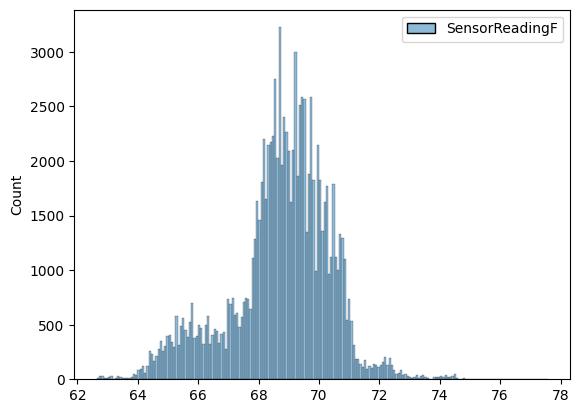

In [15]:
# Histogram of temperature. 
import seaborn, duckdb
dt = duckdb.sql("""
    SELECT SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID_Coris = 21373;
""")
seaborn.histplot(dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

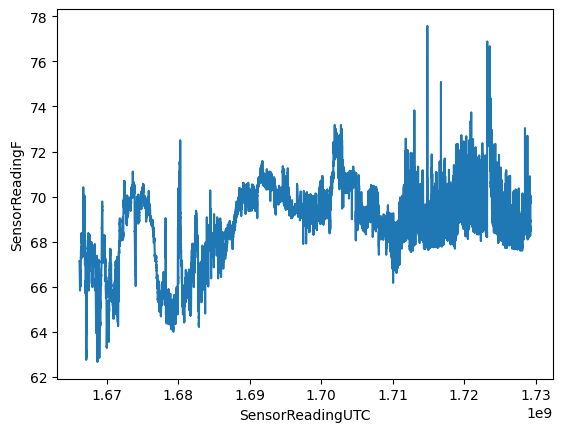

In [16]:
# Time series plot. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID_Coris = 21373;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

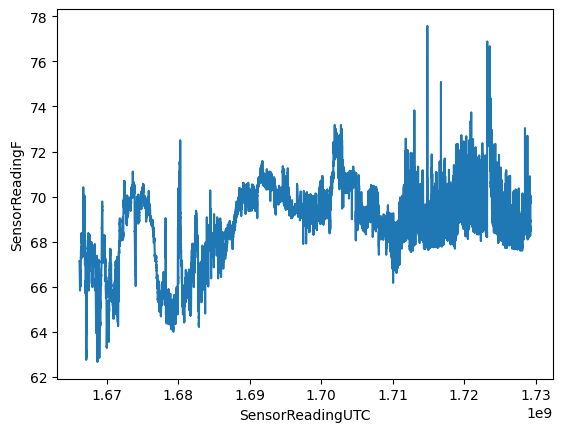

In [17]:
# Time series plot, queried from Devices instead of Sensors. 
# This is the same data, just organized in a different way. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/device_readings.parquet') 
    WHERE SensorReadingF is not null and DeviceID_Coris = 12162;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())